In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

import ipywidgets as widgets
from IPython.display import display

In [3]:
hotel_df = pd.read_csv("../artifacts/raw_data/train.csv")
hotel_df.drop(columns=["Unnamed: 0", "Booking_ID"], inplace=True)
hotel_df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,0,3,Meal Plan 1,0,Room_Type 4,56,2018,6,21,Online,0,0,0,87.32,1,Not_Canceled
1,2,0,0,1,Meal Plan 1,0,Room_Type 1,159,2018,2,13,Offline,0,0,0,70.00,0,Not_Canceled
2,2,0,0,2,Not Selected,0,Room_Type 1,86,2018,8,12,Online,0,0,0,107.10,1,Not_Canceled
3,2,0,2,3,Not Selected,0,Room_Type 1,116,2018,6,30,Online,0,0,0,75.27,0,Not_Canceled
4,2,0,1,3,Meal Plan 1,0,Room_Type 1,243,2018,11,24,Online,0,0,0,73.95,0,Canceled


# Cleanliness Check

In [4]:
hotel_df.describe()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,29020.000000,29020.000000,29020.000000,29020.000000,29020.000000,29020.000000,29020.000000,29020.000000,29020.000000,29020.000000,29020.000000,29020.000000,29020.000000,29020.000000
mean,1.845279,0.105100,0.817402,2.206892,0.031185,85.394383,2017.821330,7.419538,15.620227,0.026017,0.023225,0.156720,103.336179,0.622708
std,0.517494,0.403363,0.873181,1.419246,0.173821,85.979604,0.383082,3.070393,8.747763,0.159187,0.361599,1.772564,35.096651,0.785522
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,2018.000000,5.000000,8.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,2018.000000,8.000000,16.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,2018.000000,10.000000,23.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,2018.000000,12.000000,31.000000,1.000000,13.000000,58.000000,540.000000,5.000000


In [5]:
hotel_df.isnull().sum()

no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

In [6]:
hotel_df.duplicated().sum()

np.int64(7689)

In [7]:
hotel_df.drop_duplicates(inplace=True)
hotel_df.shape

(21331, 18)

# Analyze Cols

## Cat vars and few unique numerical vars

In [8]:
low_var_cols = ['no_of_adults', 
                           'no_of_children', 
                           'no_of_weekend_nights', 
                           'no_of_week_nights', 
                           'type_of_meal_plan',
                           'required_car_parking_space',
                           'arrival_year',
                           'arrival_month',
                           'market_segment_type',
                           'repeated_guest', 
                           'room_type_reserved', 
                           'no_of_previous_cancellations',
                           'no_of_previous_bookings_not_canceled',
                           'no_of_special_requests',
                           'booking_status']
dropdown = widgets.Dropdown(
    options=low_var_cols,
    description="Select a value",
    value=None
)

def bar_plot_variables(col='no_of_adults'):
    try:
        column = col.new 
    except AttributeError:
        column = col
    vals_dict = hotel_df[column].value_counts().to_dict()
    vals_dict = dict(sorted(vals_dict.items(), key=lambda x: x[0]))
    fig = px.bar(x=vals_dict.keys(), 
                         y=vals_dict.values(), 
                         title=" ".join(column.split("_")).title(),
                         labels = {"x": " ".join(column.split("_")).title(),
                                   "y": "Count"}
    )
    fig.show()
dropdown.observe(bar_plot_variables, names='value')

dropdown

Dropdown(description='Select a value', options=('no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_…

Data is imbalanced

## Many unique cat vars

In [9]:
many_var_cols = hotel_df.columns.difference(low_var_cols)
dropdown = widgets.Dropdown(
    options=many_var_cols,
    description="Select a value",
    value=None
)

def histogram_variables(col='arrival_date'):
    try:
        column = col.new 
    except AttributeError:
        column = col
    fig = px.histogram(hotel_df, 
                               column,
                               title=" ".join(column.split("_")).title(),
                               labels = {"x": " ".join(column.split("_")).title(),
                                         "y": "Count"}
    )
    fig.show()
dropdown.observe(histogram_variables, names='value')

dropdown

Dropdown(description='Select a value', options=('arrival_date', 'avg_price_per_room', 'lead_time'), value=None…

In [10]:
cat_cols = [
    'type_of_meal_plan',
    'required_car_parking_space',
    'room_type_reserved',
    'market_segment_type',
    'repeated_guest',
    'booking_status'
]
num_cols = hotel_df.columns.difference(cat_cols)
num_cols

Index(['arrival_date', 'arrival_month', 'arrival_year', 'avg_price_per_room',
       'lead_time', 'no_of_adults', 'no_of_children',
       'no_of_previous_bookings_not_canceled', 'no_of_previous_cancellations',
       'no_of_special_requests', 'no_of_week_nights', 'no_of_weekend_nights'],
      dtype='object')

In [11]:
def plot_bivatiate_num(df, target, num_features):
    num_plots = len(num_features)
    num_rows = (num_plots+1)//2

    fig, axes = plt.subplots(num_rows, 2, figsize=(15, num_rows*5))
    axes = axes.flatten()

    for i, column in enumerate(num_features):
        sns.boxplot(x=target, y=column, ax=axes[i], data=df, palette="Blues")
        axes[i]. set_title(f"{column} VS {target}")
    
    plt.tight_layout()
    plt.show()

In [ ]:
plot_bivatiate_num(hotel_df, 'booking_status', num_cols)

Index(['arrival_date', 'arrival_month', 'arrival_year', 'avg_price_per_room',
       'lead_time', 'no_of_adults', 'no_of_children',
       'no_of_previous_bookings_not_canceled', 'no_of_previous_cancellations',
       'no_of_special_requests', 'no_of_week_nights', 'no_of_weekend_nights'],
      dtype='object')

In [ ]:
dropdown = widgets.Dropdown(
    options=num_cols,
    description="Select a value",
    value=None
)

def cat_against_num_boxplot(col='arrival_date', target='booking_status'):
    try:
        column = col.new 
    except AttributeError:
        column = col
    fig = px.box(hotel_df, 
                         x = column,
                         y = target,
                         title=" ".join(column.split("_")).title(),
                         labels = {"x": " ".join(column.split("_")).title(),
                                   "y": "Count"},
                         color=target
    )
    fig.show()
dropdown.observe(cat_against_num_boxplot, names='value')

dropdown

Dropdown(description='Select a value', options=('arrival_date', 'arrival_month', 'arrival_year', 'avg_price_pe…

In [19]:
px.bar(hotel_df, x="arrival_month", y="avg_price_per_room")

In [20]:
cat_cols

['type_of_meal_plan',
 'required_car_parking_space',
 'room_type_reserved',
 'market_segment_type',
 'repeated_guest',
 'booking_status']

In [63]:
dropdown = widgets.Dropdown(
    options=cat_cols,
    description="Select a value",
    value=None
)

def cat_against_cat_boxplot(col='type_of_meal_plan', target='booking_status'):
    try:
        column = col.new 
    except AttributeError:
        column = col
    grouped_df = hotel_df.groupby([column, target]).size().reset_index(name="count")
    fig = px.bar(grouped_df, 
                         x = column,
                         y = "count",
                         title=" ".join(column.split("_")).title(),
                         labels = {"x": " ".join(column.split("_")).title(),
                                   "y": "Count"},
                         color=target,
                         barmode="group"
    )

    fig.show()
dropdown.observe(cat_against_cat_boxplot, names='value')

dropdown

Dropdown(description='Select a value', options=('type_of_meal_plan', 'required_car_parking_space', 'room_type_…

In [61]:
hotel_df.groupby(["required_car_parking_space", "booking_status"]).size().reset_index(name="count")

,required_car_parking_space,booking_status,count
0,0,Canceled,6011
1,0,Not_Canceled,14434
2,1,Canceled,80
3,1,Not_Canceled,806


# Data Processing

In [65]:
hotel_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21331 entries, 0 to 29019
Data columns (total 18 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_adults                          21331 non-null  int64  
 1   no_of_children                        21331 non-null  int64  
 2   no_of_weekend_nights                  21331 non-null  int64  
 3   no_of_week_nights                     21331 non-null  int64  
 4   type_of_meal_plan                     21331 non-null  object 
 5   required_car_parking_space            21331 non-null  int64  
 6   room_type_reserved                    21331 non-null  object 
 7   lead_time                             21331 non-null  int64  
 8   arrival_year                          21331 non-null  int64  
 9   arrival_month                         21331 non-null  int64  
 10  arrival_date                          21331 non-null  int64  
 11  market_segment_type 

## Object Encoding

In [66]:
from sklearn.preprocessing import LabelEncoder

In [67]:
label_encoder = LabelEncoder()

mappings = {}

for col in cat_cols:
    hotel_df[col] = label_encoder.fit_transform(hotel_df[col])

    mappings[col] = {label:code for label, code in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))}

In [68]:
mappings

{'type_of_meal_plan': {'Meal Plan 1': np.int64(0),
  'Meal Plan 2': np.int64(1),
  'Meal Plan 3': np.int64(2),
  'Not Selected': np.int64(3)},
 'required_car_parking_space': {np.int64(0): np.int64(0),
  np.int64(1): np.int64(1)},
 'room_type_reserved': {'Room_Type 1': np.int64(0),
  'Room_Type 2': np.int64(1),
  'Room_Type 3': np.int64(2),
  'Room_Type 4': np.int64(3),
  'Room_Type 5': np.int64(4),
  'Room_Type 6': np.int64(5),
  'Room_Type 7': np.int64(6)},
 'market_segment_type': {'Aviation': np.int64(0),
  'Complementary': np.int64(1),
  'Corporate': np.int64(2),
  'Offline': np.int64(3),
  'Online': np.int64(4)},
 'repeated_guest': {np.int64(0): np.int64(0), np.int64(1): np.int64(1)},
 'booking_status': {'Canceled': np.int64(0), 'Not_Canceled': np.int64(1)}}

In [72]:
hotel_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21331 entries, 0 to 29019
Data columns (total 18 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_adults                          21331 non-null  int64  
 1   no_of_children                        21331 non-null  int64  
 2   no_of_weekend_nights                  21331 non-null  int64  
 3   no_of_week_nights                     21331 non-null  int64  
 4   type_of_meal_plan                     21331 non-null  int64  
 5   required_car_parking_space            21331 non-null  int64  
 6   room_type_reserved                    21331 non-null  int64  
 7   lead_time                             21331 non-null  int64  
 8   arrival_year                          21331 non-null  int64  
 9   arrival_month                         21331 non-null  int64  
 10  arrival_date                          21331 non-null  int64  
 11  market_segment_type 

# Check for Multicollinearity

In [73]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [80]:
X = add_constant(hotel_df)
vif_data = pd.DataFrame()
vif_data["feature"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

In [82]:
vif_data

,feature
0,4.135966e+07
1,1.338058e+00
2,1.275359e+00
3,1.076530e+00
4,1.130114e+00
5,1.175411e+00
6,1.034692e+00
7,1.546397e+00
8,1.404182e+00
9,1.291174e+00


Vif below 5-6 so there is no multicollinearity

<Axes: >

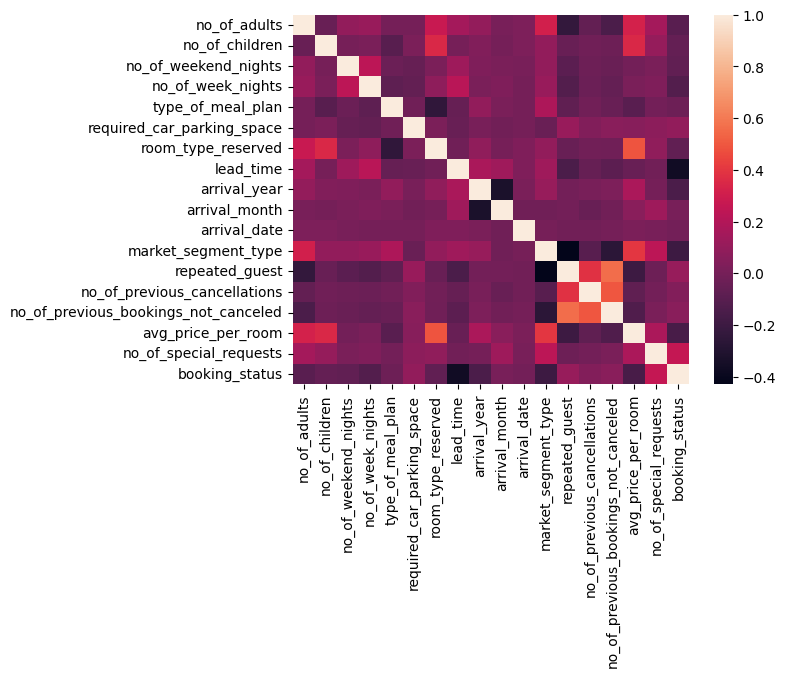

In [88]:
sns.heatmap(hotel_df.corr())

# Check for Skewness

In [94]:
skewness = hotel_df.skew()
skewness

no_of_adults                            -0.302265
no_of_children                           4.220585
no_of_weekend_nights                     0.657812
no_of_week_nights                        1.638660
type_of_meal_plan                        1.642162
required_car_parking_space               4.595860
room_type_reserved                       1.396108
lead_time                                1.402344
arrival_year                            -1.966542
arrival_month                           -0.286785
arrival_date                             0.003251
market_segment_type                     -2.341571
repeated_guest                           5.282723
no_of_previous_cancellations            13.276320
no_of_previous_bookings_not_canceled     7.598112
avg_price_per_room                       0.637845
no_of_special_requests                   0.913927
booking_status                          -0.949658
dtype: float64

Some big skew in a couple of variables. Will do a log transformation.

In [92]:
for col in hotel_df.columns:
    if skewness[col]>5:
        hotel_df[col] = np.log1p(hotel_df[col])

# Handle Imbalanced data

In [96]:
hotel_df["booking_status"].value_counts()

booking_status
1    15240
0     6091
Name: count, dtype: int64

Overbalance data

In [97]:
X = hotel_df.drop(columns=['booking_status'])
y = hotel_df["booking_status"]

In [99]:
from imblearn.over_sampling import SMOTE

In [101]:
smote = SMOTE(random_state=30)

X_res, y_res = smote.fit_resample(X, y)

In [104]:
y_res.value_counts()

booking_status
1    15240
0    15240
Name: count, dtype: int64

In [105]:
balanced_df = pd.DataFrame(X_res, columns=X.columns)
balanced_df["booking_status"] = y_res

In [107]:
balanced_df

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,0,3,0,0,3,56,2018,6,21,4,0.0,0.0,0.0,87.320000,1,1
1,2,0,0,1,0,0,0,159,2018,2,13,3,0.0,0.0,0.0,70.000000,0,1
2,2,0,0,2,3,0,0,86,2018,8,12,4,0.0,0.0,0.0,107.100000,1,1
3,2,0,2,3,3,0,0,116,2018,6,30,4,0.0,0.0,0.0,75.270000,0,1
4,2,0,1,3,0,0,0,243,2018,11,24,4,0.0,0.0,0.0,73.950000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30475,1,0,1,1,2,0,0,73,2017,4,3,4,0.0,0.0,0.0,73.349992,0,0
30476,3,0,1,2,0,1,3,161,2018,7,14,4,0.0,0.0,0.0,145.642331,2,0
30477,1,0,1,2,0,0,0,278,2018,9,16,3,0.0,0.0,0.0,100.111664,0,0
30478,2,0,0,1,3,0,0,1,2018,7,7,4,0.0,0.0,0.0,139.000000,0,0


In [108]:
hotel_df = balanced_df.copy()

# Feature Selection  
random forrest

In [109]:
from sklearn.ensemble import RandomForestClassifier

In [110]:
X = hotel_df.drop(columns=['booking_status'])
y = hotel_df["booking_status"]

In [111]:
model = RandomForestClassifier(random_state=30)
model.fit(X, y)

RandomForestClassifier(random_state=30)

In [112]:
feature_importance = model.feature_importances_
feature_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": feature_importance
})

In [119]:
feature_importance_df.sort_values(by="importance", ascending=False, inplace=True)
feature_importance_df

,feature,importance
7,lead_time,0.259260
16,no_of_special_requests,0.184285
15,avg_price_per_room,0.152808
9,arrival_month,0.086124
10,arrival_date,0.082530
11,market_segment_type,0.053592
3,no_of_week_nights,0.045364
2,no_of_weekend_nights,0.030660
4,type_of_meal_plan,0.022696
6,room_type_reserved,0.019081


In [124]:
top_10_features = feature_importance_df["feature"][:10].values

In [128]:
reduced_features_df = hotel_df[top_10_features.tolist() + ["booking_status"]]
hotel_df = reduced_features_df.copy()
hotel_df

,lead_time,no_of_special_requests,avg_price_per_room,arrival_month,arrival_date,market_segment_type,no_of_week_nights,no_of_weekend_nights,type_of_meal_plan,room_type_reserved,booking_status
0,56,1,87.320000,6,21,4,3,0,0,3,1
1,159,0,70.000000,2,13,3,1,0,0,0,1
2,86,1,107.100000,8,12,4,2,0,3,0,1
3,116,0,75.270000,6,30,4,3,2,3,0,1
4,243,0,73.950000,11,24,4,3,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
30475,73,0,73.349992,4,3,4,1,1,2,0,0
30476,161,2,145.642331,7,14,4,2,1,0,3,0
30477,278,0,100.111664,9,16,3,2,1,0,0,0
30478,1,0,139.000000,7,7,4,1,0,3,0,0


# Model Selection

In [135]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

In [130]:
X = hotel_df.drop(columns=["booking_status"])
y = hotel_df["booking_status"]

In [131]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30)

In [132]:
classifiers = {
    "Logistic Regression": LogisticRegression(random_state=30),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=30),
    "Random Forest": RandomForestClassifier(random_state=30),
    "SVM": SVC(random_state=30),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=30),
    "XGBoost": XGBClassifier(random_state=30),
    "LightGBM": LGBMClassifier(random_state=30),
    "AdaBoost": AdaBoostClassifier(random_state=30)
}

In [133]:
metrics = {
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1 Score": []

}

In [136]:
for model_name, classifier in classifiers.items():
    classifier.fit(X_train, y_train)

    y_pred = classifier.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    metrics["Model"].append(model_name)
    metrics["Accuracy"].append(accuracy)
    metrics["Precision"].append(precision)
    metrics["Recall"].append(recall)
    metrics["F1 Score"].append(f1)

/Users/efosazuwa/code/mlops-beginner-to-advanced/hotel_reservations/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



[LightGBM] [Info] Number of positive: 12141, number of negative: 12243
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000864 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 602
[LightGBM] [Info] Number of data points in the train set: 24384, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.497908 -> initscore=-0.008366
[LightGBM] [Info] Start training from score -0.008366


In [138]:
metrics_df = pd.DataFrame(metrics)
metrics_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.785925,0.815845,0.747661,0.780266
1,KNN,0.781660,0.848306,0.694740,0.763881
2,Decision Tree,0.837106,0.846154,0.830591,0.838300
3,Random Forest,0.884678,0.888961,0.883511,0.886228
4,SVM,0.723753,0.729039,0.726686,0.727860
5,Naive Bayes,0.775591,0.804004,0.738625,0.769929
6,Gradient Boosting,0.846129,0.832564,0.872862,0.852237
7,XGBoost,0.874180,0.876615,0.875766,0.876190
8,LightGBM,0.867618,0.861742,0.880929,0.871230
9,AdaBoost,0.806102,0.819607,0.793159,0.806166


# Train Random Forrest(Hyperparameter Tuning)

In [166]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

In [167]:
rf = RandomForestClassifier(random_state=30)

In [168]:
params_dist = {
    "n_estimators": randint(100, 500),
    "max_depth": randint(10, 50),
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 5),
    "bootstrap": [True, False]
}

In [176]:
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=params_dist,
    n_iter=10,
    cv = 5,
    verbose=2,
    random_state=30,
    scoring='accuracy'
)

In [177]:
random_search.fit(X_train, y_train)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END bootstrap=False, max_depth=47, min_samples_leaf=2, min_samples_split=7, n_estimators=240; total time=   4.7s
[CV] END bootstrap=False, max_depth=47, min_samples_leaf=2, min_samples_split=7, n_estimators=240; total time=   5.1s
[CV] END bootstrap=False, max_depth=47, min_samples_leaf=2, min_samples_split=7, n_estimators=240; total time=   4.7s
[CV] END bootstrap=False, max_depth=47, min_samples_leaf=2, min_samples_split=7, n_estimators=240; total time=   4.7s
[CV] END bootstrap=False, max_depth=47, min_samples_leaf=2, min_samples_split=7, n_estimators=240; total time=   4.7s
[CV] END bootstrap=False, max_depth=12, min_samples_leaf=2, min_samples_split=5, n_estimators=245; total time=   3.6s
[CV] END bootstrap=False, max_depth=12, min_samples_leaf=2, min_samples_split=5, n_estimators=245; total time=   3.6s
[CV] END bootstrap=False, max_depth=12, min_samples_leaf=2, min_samples_split=5, n_estimators=245; total time=   

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=30),
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x16d3507c0>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x16e687af0>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x16e684820>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x16e686410>},
                   random_state=30, scoring='accuracy', verbose=2)

In [178]:
random_search.best_params_

{'bootstrap': False,
 'max_depth': 38,
 'min_samples_leaf': 2,
 'min_samples_split': 4,
 'n_estimators': 447}

In [179]:
best_rf_model = random_search.best_estimator_

In [180]:
y_pred = best_rf_model.predict(X_test)

In [181]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [182]:
print(f"Accuracy: {accuracy}", 
      f"Precision: {precision}",
      f"Recall: {recall}",
      f"F1: {f1}")

Accuracy: 0.8876312335958005 Precision: 0.8861164427383237 Recall: 0.8938367215230719 F1: 0.8899598393574297


# Save Model

In [183]:
import joblib

In [186]:
joblib.dump(best_rf_model, "../artifacts/model/random_forest.pkl")

['../artifacts/model/random_forest.pkl']

In [187]:
loaded_model=joblib.load("../artifacts/model/random_forest.pkl")

In [202]:
loaded_model.predict(X_train.iloc[0,:].values.reshape(1,-1))

/Users/efosazuwa/code/mlops-beginner-to-advanced/hotel_reservations/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but RandomForestClassifier was fitted with feature names



array([1])

In [ ]:
y_train.iloc[0]

np.int64(1)